# Introduction:

**Problem Statement:**

Suppose you are a data scientist working for a bank that recently conducted a marketing campaign to promote term deposits to its clients. The bank collected data on various client characteristics, such as age, job type, marital status, education level, and more. Your task is to analyze this dataset and build a machine learning model to predict whether a client will subscribe to a term deposit or not.

<center><img src="https://img.etimg.com/thumb/width-420,height-315,imgsize-51456,resizemode-75,msid-110798763/markets/stocks/news/will-short-term-narrative-headwinds-for-psu-banks-bring-back-mojo-to-private-sector-banks-5-banks-with-an-upside-potential-of-up-to-24/bankk.jpg"/></center>

By accurately predicting client subscription behavior, your model will enable the bank to optimize its marketing efforts. It will help identify potential clients who are more likely to subscribe to the term deposit, allowing the bank to focus its resources on targeting these individuals. This targeted approach will not only increase the effectiveness of the marketing campaign but also maximize the bank's return on investment.

# STEP 1: Import the necessary Libraries

In [2]:
# Import the necessary libraries
# Data manipulation and numerical operationsimport pandas as pd
import numpy as np
import pandas as pd
import os
# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Machine learning model metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

# Setting maximum limit of the number of columns visible
pd.set_option('display.max_columns', 30)

# STEP 2: Loading the Data

**Dataset Information:**
Content: Each row represents a customer, and each column contains attributes related to the customer's socio-economic background, bank contact information, and the outcome of a marketing campaign.

The dataset includes information about:

- **Demographic Information:** Age, job type, marital status, education level, whether the customer has a loan or housing loan, and whether they have defaulted on a loan.

- **Bank Contact Information:** The method of contact (cellular, telephone), last contact month, last contact day of the week, duration of the last contact, and number of contacts performed during this campaign.

- **Socio-Economic Indicators:** Employment variation rate, consumer price index, consumer confidence index, Euribor 3-month rate, and the number of employees.

- **Campaign Outcome:** Whether the client has subscribed to a term deposit (the column is called y).

### 2.1 Load the data & view it

*Hint: Use `;` as the delimiter.*

In [3]:
# Loading the data

# 1. Define your localized Git structure path
data_path = "data/bank_data.csv"

# 2. Smart fallback if running on Google Colab
if not os.path.exists(data_path):
    from google.colab import drive
    drive.mount('/content/drive',force_remount=True)
    data_path = "/content/drive/MyDrive/Colab Notebooks/bank_data.csv"

# 3. Load the data using the resolved path
df = pd.read_csv(data_path,sep=';')

df.head()

Mounted at /content/drive


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### 2.2 View the columns of the data and understand them

In [6]:
# View the columns of the dataset
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

### 2.3 Check the shape of the dataset

In [7]:
# Checking the shape of the data
df.shape

(41188, 21)

### 2.4 Understand the datatypes of each of the columns

In [8]:
# Check the dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

# STEP 3: EDA

### 3.1 Check the distribution of the target variable - `y`.

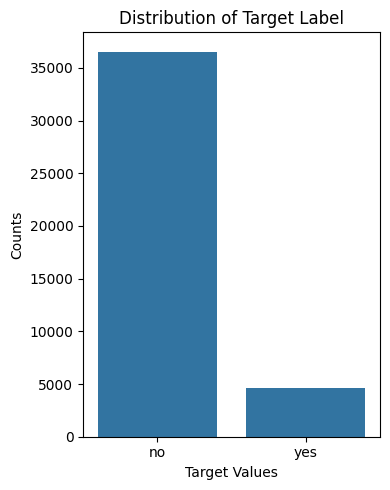

In [9]:

# Checking the distribution of the target variable 'y'

# Set the figure size for better readability
plt.figure(figsize=(4,5))
# Create a count plot for the 'y' variable in the dataset
sns.countplot(data=df,x='y')
# Add a title to the plot
plt.title("Distribution of Target Label")
# Label the x-axis
plt.xlabel("Target Values")
# Label the y-axis
plt.ylabel("Counts")
# Display the plot
plt.tight_layout()
plt.show()

### 3.2 Do an analysis of the `Subscription Rate` variable wrt all the categorical variables

*Hint: Use normalized values to plot to avoid the class imbalance problem.*

In [10]:
# Listing all the categorical columns

#num_cols=df.select_dtypes(exclude=['object', 'category']).columns.to_list()
#problem with above is it will include date time type if present

#Best way is to take this from X_train after splitting:
# 1. Identify categorical columns and safely remove the target 'y'
cat_cols = df.select_dtypes(include=['object', 'category']).columns.to_list()
if 'y' in cat_cols:
    cat_cols.remove('y')

# 2. Identify numerical columns and safely remove the target 'y'
num_cols = df.select_dtypes(include=['number']).columns.to_list()
if 'y' in num_cols:
    num_cols.remove('y')

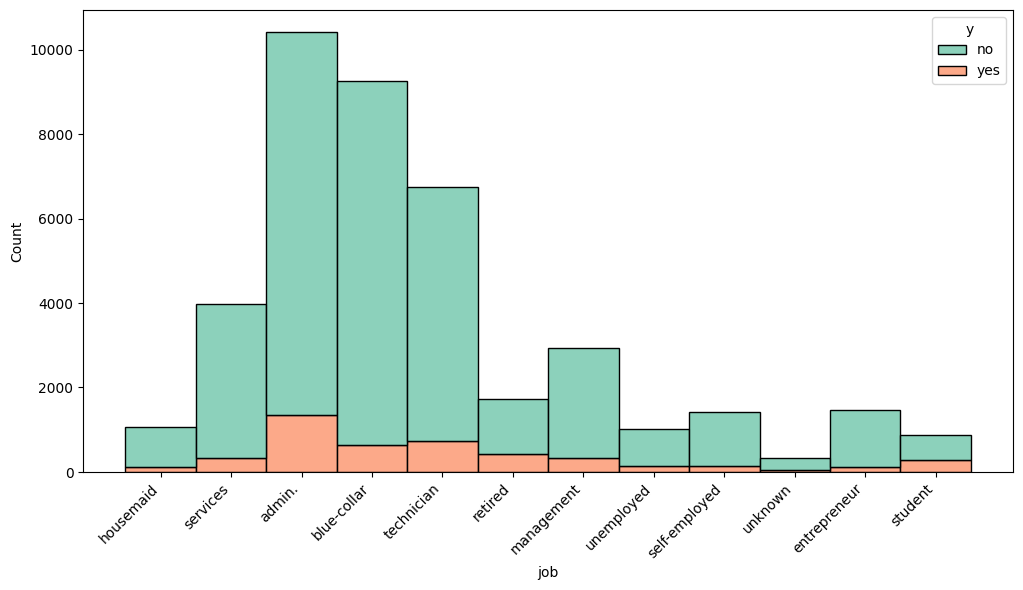

In [11]:
#lets explore jobs vs target distribution
plt.figure(figsize=(12,6))
sns.histplot(data=df,x='job',hue='y',multiple='stack',palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.show()

1. The Volume Drivers (The Bulk of Data)admin. and blue-collar jobs dominate your dataset: They represent the highest total volume of applications by a massive margin.technician and services follow closely: Together, these four categories make up the vast majority of your training instances.
2. Class Imbalance is Extreme Across the Boardno heavily dominates every job type: Just like your overall target column, the proportion of yes cases (orange) is tiny compared to the no cases (green) for every single job category.Potential Model Bias: If you don't use techniques like class weights, a machine learning model will easily learn to predict no for a blue-collar or admin. worker simply because of the overwhelming raw volume of green bars.
3. Conversion / Success Rate Differences (Hidden Proportions)While raw counts are hard to eyeball due to the imbalance, we can spot distinct behavioral differences between the groups:High Conversion Potential (student and retired): Look at the orange bars relative to their overall heights. Students and retired applicants appear to have a visibly higher ratio of yes responses relative to their total volume compared to categories like blue-collar.Low Conversion Potential (blue-collar and services): Even though blue-collar has an enormous number of applicants, their orange yes block is quite flat. This suggests this segment has a very low conversion rate for the loan product.

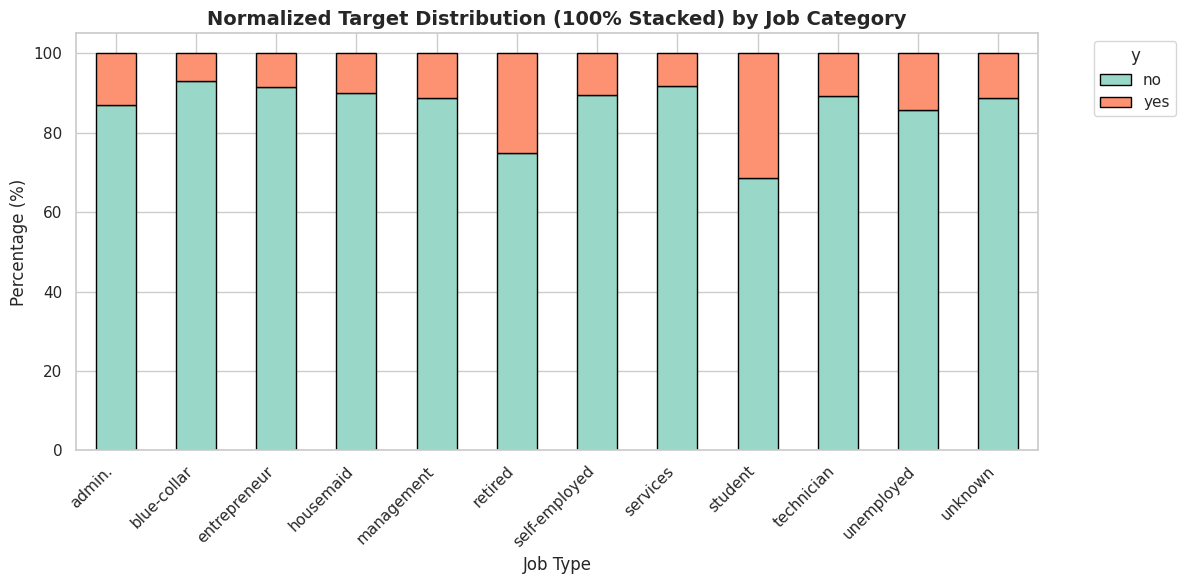

In [12]:
#lets normalize the bars to a 100% Stacked Bar Chart.
#This scales all job columns to an identical height so you can directly compare the percentage of yes vs no

# y_job_100_normalized=pd.crosstab(df['job'],df['y'],normalize='index')*100
# y_job_100_normalized.plot(kind='bar',stacked=True)

# 1. Calculate percentage distribution per job category
# rows = job categories, columns = yes/no values
job_y_pct = pd.crosstab(df['job'], df['y'], normalize='index') * 100

# 2. Set up the plotting theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 3. Plot stacked bars (match your colors roughly with a custom palette)
job_y_pct.plot(
    kind='bar',
    stacked=True,
    color=['#99d8c9', '#fc9272'], # Matching your green and orange palette
    edgecolor='black',
    ax=plt.gca()
)

# 4. Rotate labels and adjust text alignment
plt.xticks(rotation=45, ha='right')

# 5. Clean up labels
plt.title('Normalized Target Distribution (100% Stacked) by Job Category', fontsize=14, fontweight='bold')
plt.xlabel('Job Type', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='y', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [13]:
len(cat_cols)

10

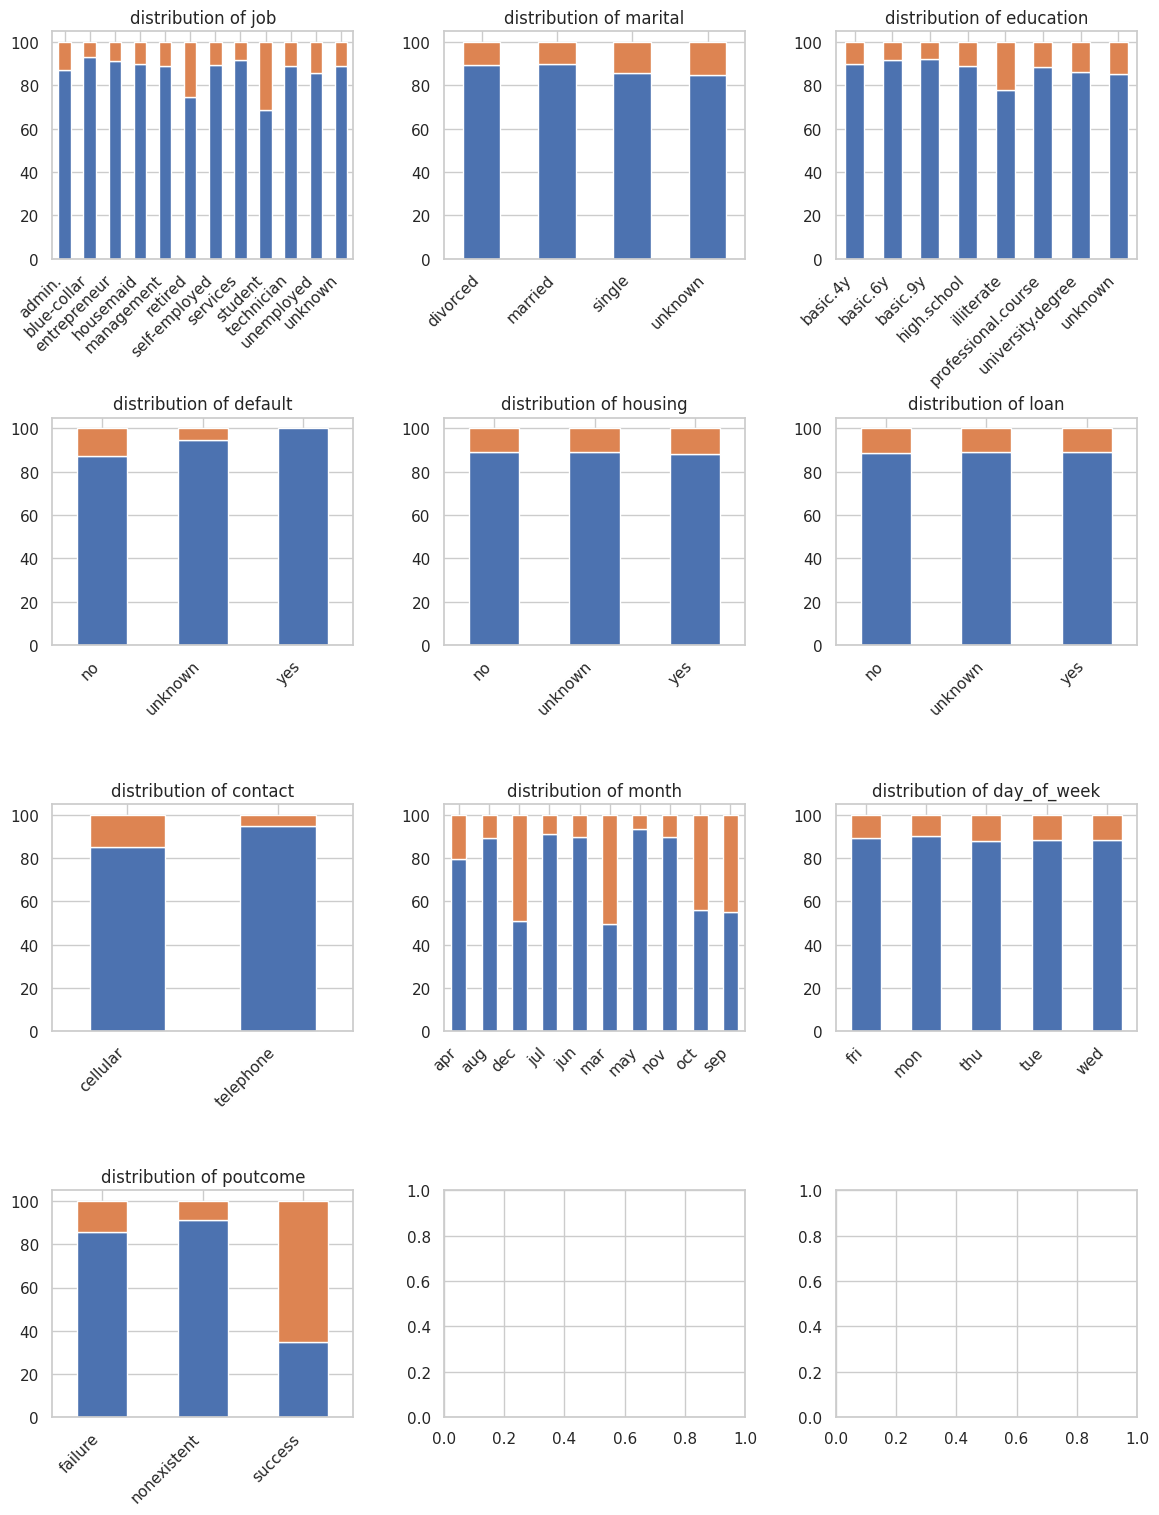

In [14]:

# Visualize the data
# Setting up the subplot grid

fig,ax=plt.subplots(4,3,figsize=(14,18))
ax=ax.flatten()
# Plotting each categorical feature in a subplot

for i,col in enumerate(cat_cols):
  cat_pct=pd.crosstab(df[col],df['y'],normalize='index')*100
  cat_pct.plot(kind='bar',stacked=True,ax=ax[i],legend=False)
  ax[i].tick_params(axis='x', rotation=45)
  ax[i].set_title(f'distribution of {col}')
  ax[i].set_xlabel('')
  # FIX : Pivot labels from their right edge so they slant safely to the left
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right')
plt.subplots_adjust(hspace=0.7, wspace=0.3)
plt.show()

    # Plotting the normalized counts as bar plots


    # Setting title and labels


# Adjusting layout


# 📊 Comprehensive Categorical EDA & Feature Engineering Strategy
*Dataset: Bank Marketing Dataset | Target variable 'y' ('yes' / 'no')*

---

### 🧠 The Core Metric for Categorical Assessment
When looking at stacked percentage plots against a binary target, we evaluate the **variance of the target proportion (the orange bars) across categories**.
*   **High target variance** across groups = High predictive signal $\rightarrow$ **KEEP & ENCODE**.
*   **Flat/Uniform target lines** across groups = Zero predictive signal $\rightarrow$ **DROP**.
*   **Missing/Empty categories** = Zero variance $\rightarrow$ **DROP DUE TO IMBALANCE**.

---

### 1. High-Signal Features (Decision: KEEP & ENCODE)

These features demonstrate dramatic variance in the target distribution, providing strong discriminative boundaries for machine learning models.

*   **`poutcome` (Previous Campaign Outcome):**
    *   *Observation:* The `success` category shows a massive conversion rate (~65%) compared to `failure` and `nonexistent` (~10-15%).
    *   *Action:* **Keep as-is.** This is the strongest baseline categorical predictor in the dataset.
*   **`month` (Last Contact Month):**
    *   *Observation:* Highly volatile seasonal trends. Off-peak months like `mar`, `sep`, `oct`, and `dec` display exceptionally high conversion rates (~50%), while high-volume summer months are low.
    *   *Action:* **Keep and Target Encode** or One-Hot Encode. This allows tree models to make clean splits on high-performing seasonal windows.
*   **`job` & `education`:**
    *   *Observation:* Noticeable demographic variance. `student` and `retired` convert at significantly higher rates (~25-30%) than blue-collar or services (~10%).
    *   *Action:* **Keep and Group.** To handle high cardinality, combine rare sub-categories representing $<5\%$ of total rows into an `'other'` bucket, then One-Hot Encode.
*   **`contact` (Communication Type):**
    *   *Observation:* Customers contacted via `cellular` show a distinctly higher conversion rate than traditional `telephone` contacts.
    *   *Action:* **Keep and Binary Encode** (0 for telephone, 1 for cellular).

---

### 2. Zero-Signal Features (Decision: DROP)

These features have flat target distributions across all sub-categories, adding dimensional weight without adding any predictive intelligence.

*   **`day_of_week`:**
    *   *Observation:* The orange 'yes' bar is perfectly uniform from Monday through Friday. Customers convert at the exact same rate regardless of the weekday.
    *   *Action:* **Drop completely.** It provides zero variance or discriminatory power.
*   **`housing` (Housing Loan) & `loan` (Personal Loan):**
    *   *Observation:* Counter-intuitively, the ratio of conversion remains stubbornly flat whether a customer holds a housing loan, personal loan, or no debt at all.
    *   *Action:* **Drop or Deprioritize.** These attributes act as model noise rather than predictive signal.
*   **`marital`:**
    *   *Observation:* The conversion rates across `divorced`, `married`, and `single` remain closely clustered with minimal variation.
    *   *Action:* **Drop or evaluate as a low-priority feature.**

---

### 3. Fatal Class Imbalance (Decision: DROP)

*   **`default` (Credit in Default):**
    *   *Observation:* The `yes` bar is virtually empty because almost nobody in the dataset has a confirmed history of default (only 3 rows out of 41,188).
    *   *Action:* **Drop entirely due to Near-Zero Variance (NZV).** Leaving a categorical value with near-zero occurrences adds structural sparsity to your matrix and risks extreme model overfitting on a microscopic sample size anomaly.

---

### 🎙️ The Senior-Level Interview Wrap-Up Pitch

> *"When analyzing our categorical distribution charts against the target, I categorize them into an actionable three-tier framework rather than just observing their shapes.*
>
> *First, I will **Keep and Encode** features like `poutcome`, `month`, and `job` because their target boundaries shift drastically, providing deep predictive signal for our model to optimize on. Second, I will **Drop** features like `day_of_week`, `housing`, and `loan` because their conversion lines are completely flat—meaning they offer zero discriminative variance. Finally, I will **Drop `default` due to severe class imbalance**, as a near-zero variance column adds mathematical noise and introduces major overfitting risks on microscopic sample sizes."*


# STEP 4: Feature Engineering

### 4.1 Do a correlation analysis of the data

In [15]:
num_cols

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

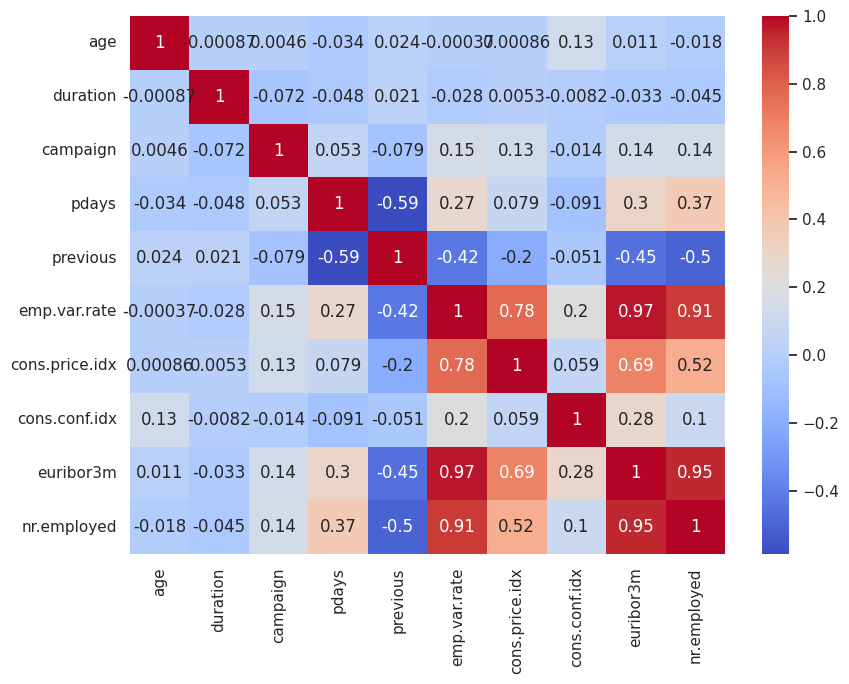

In [16]:
#Correlation analysis of the dataset
# Set the figure size to make the heatmap more readable
plt.figure(figsize=(9,7))
corr=df[num_cols].corr()
sns.heatmap(data=corr,cmap='coolwarm',annot=True)
plt.tight_layout()
plt.show()
# Create a heatmap to visualize the correlation matrix of the numeric features in the dataset

# Display the heatmap


# 📝 Interview Note: Correlation Matrix & Feature Engineering Strategy
*Dataset Context: Bank Marketing Dataset (Economic & Campaign Attributes)*

---

### 1. Key Findings & Strategic Actions (What to Tell the Interviewer)

#### 🔥 Issue A: The Macroeconomic Tri-Cluster (Severe Multicollinearity)
*   **The Pairs:**
    *   `euribor3m` vs. `emp.var.rate` (Correlation: **0.97**)
    *   `nr.employed` vs. `emp.var.rate` (Correlation: **0.91**)
    *   `euribor3m` vs. `nr.employed` (Correlation: **0.95**)
*   **The Interpretation:** These are highly redundant macroeconomic indicators. When the economy expands, the Employment Variation Rate (`emp.var.rate`) rises, companies hire more staff (`nr.employed`), and central bank interest rates (`euribor3m`) go up simultaneously.
*   **The Interview Pitch:**
    > *"I notice a severe tri-cluster of multicollinearity among the macroeconomic features. Keeping all three will destabilize linear models and warp tree-based feature importances. To fix this, I will check their relationship against the target variable and keep only the strongest predictor, dropping the other two. Alternatively, I could run a Variance Inflation Factor (VIF) test or use PCA to condense them into a single 'Economic Health' index."*

#### 📉 Issue B: Negative but Logical Relationships
*   **The Pair:** `previous` vs. `pdays` (Correlation: **-0.59**)
*   **The Interpretation:** This is a moderate negative correlation that makes perfect sense. `pdays` tracks days since the last contact (where 999 means never contacted), while `previous` counts total past contacts. More past contacts naturally means fewer days have passed since a conversation.
*   **The Interview Pitch:**
    > *"The moderate negative correlation between `previous` and `pdays` is acceptable to keep because the signal isn't completely redundant. However, because `pdays` often contains a placeholder flag like 999 for missing values, I would consider engineering a clean, binary feature like `is_missing_pdays` or `has_prior_contact` to capture this relationship more effectively."*

#### 💤 Issue C: Low-Signal Features (Near-Zero Correlation)
*   **The Features:** `age` and `campaign`
*   **The Interpretation:** These show virtually no linear correlation with any other variables in the matrix (mostly bouncing between -0.07 and 0.15).
*   **The Interview Pitch:**
    > *"While `age` and `campaign` don't present any multicollinearity concerns, they have near-zero linear correlation with the rest of the dataset. Before dismissing them, I will evaluate their non-linear relationships against the target variable using Mutual Information scores or tree-based feature importance thresholds."*

---

### 2. Live Interview Cheat Code: The 3-Step Framing Framework
When an interviewer points at a heatmap and asks, *"What do you see?"*, structure your answer using this exact progression to show senior-level thinking:

1.  **Spot & State:** Name the exact coordinates and numbers (e.g., *"I see a near-perfect 0.97 correlation between X and Y"*).
2.  **Explain the 'Why' (Domain Knowledge):** Explain the real-world business or economic logic behind the numbers (e.g., *"This makes sense because interest rates and employment trends move together in an economic expansion"*).
3.  **Propose the Next Engineering Action:** Don't just find the problem; state how you will test and fix it (e.g., *"Because of this, I will check their VIF scores, look at their individual relationship to our target, and drop the redundant columns before training"*).


Standard Pearson correlation requires both variables to be continuous numbers. Since our target 'y' is binary (yes/no), we must use a Point-Biserial correlation instead. It tells us if higher values of our macro indicators linearly move the probability of a 'yes' up or down.

Mutual Information/Information Gain (non-linear choice) measures how much information a feature shares with the target variable.
Unlike correlation matrices which only find straight-line, linear relationships, Mutual Information catches any structural pattern—including curves and non-linear relationships. It scores features on a scale from 0 upward; a higher score means the feature shares a lot of predictive 'signal' with our target variable.

In [17]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.feature_selection import mutual_info_classif

# 1. Define your collinear macroeconomic cluster
macro_cols = ['euribor3m', 'emp.var.rate', 'nr.employed']

# 2. Map string target ('yes'/'no') to binary numeric values (1/0)
y_numeric = df['y'].map({'yes': 1, 'no': 0})

print("==== METHOD 1: POINT-BISERIAL CORRELATION WITH TARGET ====")
# Measures the linear strength between a continuous feature and a binary target
pb_results = {}
for col in macro_cols:
    correlation, p_value = stats.pointbiserialr(df[col], y_numeric)
    pb_results[col] = abs(correlation)  # We evaluate the magnitude (absolute value)
    print(f"{col:<13} | Absolute Correlation: {abs(correlation):.4f} (p-value: {p_value:.4e})")

best_pb_feature = max(pb_results, key=pb_results.get)
print(f"👉 Linear Selection Strategy: Keep '{best_pb_feature}' and drop the other two.")


print("\n==== METHOD 2: MUTUAL INFORMATION (INFORMATION GAIN) ====")
# Measures any structural relationship (both linear and non-linear)
mi_scores = mutual_info_classif(df[macro_cols], y_numeric, random_state=42)
mi_results = dict(zip(macro_cols, mi_scores))

for col, score in mi_results.items():
    print(f"{col:<13} | Information Gain Score: {score:.4f}")

best_mi_feature = max(mi_results, key=mi_results.get)
print(f"👉 Non-Linear Selection Strategy: Keep '{best_mi_feature}' and drop the other two.")


print("\n==== ACTION: DROPPING REDUNDANT COLUMNS ====")
# Dynamically keep the highest performing feature based on your test choice (e.g., Mutual Info)
feature_to_keep = best_mi_feature
features_to_drop = [col for col in macro_cols if col != feature_to_keep]

df_cleaned = df.drop(columns=features_to_drop)
print(f"Successfully dropped redundant features: {features_to_drop}")
print(f"Preserved high-signal feature: '{feature_to_keep}'")


==== METHOD 1: POINT-BISERIAL CORRELATION WITH TARGET ====
euribor3m     | Absolute Correlation: 0.3078 (p-value: 0.0000e+00)
emp.var.rate  | Absolute Correlation: 0.2983 (p-value: 0.0000e+00)
nr.employed   | Absolute Correlation: 0.3547 (p-value: 0.0000e+00)
👉 Linear Selection Strategy: Keep 'nr.employed' and drop the other two.

==== METHOD 2: MUTUAL INFORMATION (INFORMATION GAIN) ====
euribor3m     | Information Gain Score: 0.0762
emp.var.rate  | Information Gain Score: 0.0550
nr.employed   | Information Gain Score: 0.0643
👉 Non-Linear Selection Strategy: Keep 'euribor3m' and drop the other two.

==== ACTION: DROPPING REDUNDANT COLUMNS ====
Successfully dropped redundant features: ['emp.var.rate', 'nr.employed']
Preserved high-signal feature: 'euribor3m'


### ⚖️ The Macroeconomic Conflict: Linear vs. Non-Linear Selection

#### 1. What the Results Show
*   **Point-Biserial (Linear):** `nr.employed` has the strongest purely straight-line relationship with the target (`0.3547`).
*   **Mutual Information (Non-Linear):** `euribor3m` has the highest overall information overlap (`0.0762`), capturing both linear and non-linear patterns.

#### 2. The Final Recommendation (Which one to keep?)
The decision depends entirely on the machine learning algorithm planned for the pipeline:

*   **Scenario A: If using Linear/Distance-Based Models (Logistic Regression, SVM)**
    *   *Decision:* Keep **`nr.employed`**.
    *   *Reasoning:* Linear models cannot naturally capture complex curves. They rely entirely on straight-line correlations. `nr.employed` provides the cleanest linear signal.
*   **Scenario B: If using Tree-Based/Non-Linear Models (XGBoost, LightGBM, Random Forest)**
    *   *Decision:* Keep **`euribor3m`**.
    *   *Reasoning:* Tree-based models naturally uncover non-linear interactions. Since Mutual Information captures both linear and non-linear patterns, `euribor3m` contains more total structural "signal" for a tree to exploit.


In [18]:
#Low signal features:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

# 1. Isolate low-correlation features and prepare the binary target
low_signal_cols = ['age', 'campaign']
X_low = df[low_signal_cols]
y_numeric = df['y'].map({'yes': 1, 'no': 0})

print("==== STEP 1: MUTUAL INFORMATION (NON-LINEAR CAPTURE) ====")
# Measures general dependencies (both linear and complex curved relationships)
mi_scores = mutual_info_classif(X_low, y_numeric, random_state=42)
mi_results = dict(zip(low_signal_cols, mi_scores))

for col, score in mi_results.items():
    print(f"'{col}' Mutual Information Score : {score:.4f}")


print("\n==== STEP 2: TREE-BASED FEATURE IMPORTANCE ====")
# Fits a non-linear tree model to extract structural predictive power
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_low, y_numeric)
rf_importances = dict(zip(low_signal_cols, rf.feature_importances_))

for col, importance in rf_importances.items():
    print(f"'{col}' Tree Gini Importance Score: {importance:.4f}")


print("\n==== STEP 3: ANALYTICAL CONCLUSION ====")
# Evaluate if non-linear signals exist despite low linear correlation
for col in low_signal_cols:
    if mi_results[col] > 0.005 or rf_importances[col] > 0.10:
        print(f"✅ KEEP '{col}': Hidden non-linear signal detected! Tree model exploits it.")
    else:
        print(f"❌ DROP '{col}': Confirmed zero signal across linear, non-linear, and tree metrics.")


==== STEP 1: MUTUAL INFORMATION (NON-LINEAR CAPTURE) ====
'age' Mutual Information Score : 0.0130
'campaign' Mutual Information Score : 0.0069

==== STEP 2: TREE-BASED FEATURE IMPORTANCE ====
'age' Tree Gini Importance Score: 0.8741
'campaign' Tree Gini Importance Score: 0.1259

==== STEP 3: ANALYTICAL CONCLUSION ====
✅ KEEP 'age': Hidden non-linear signal detected! Tree model exploits it.
✅ KEEP 'campaign': Hidden non-linear signal detected! Tree model exploits it.


mi_score > 0.05 strong signal Must keep

mi_score 0.01 to 0.05 moderate signal keep

< 0.001 noise can drop

# 📈 Module: Linear Feature Selection with a Continuous Target
*Scenario: Target variable 'y' is a continuous numerical value (e.g., revenue, price, score).*

### 🧠 The Strategy
When dealing with a **continuous target**, we can use standard Pearson Correlation ($r$) to evaluate our features.
To resolve our **Macroeconomic Tri-Cluster Multicollinearity** (`euribor3m`, `emp.var.rate`, `nr.employed`), we find each feature's direct linear correlation to `'y'`. We **keep the single feature with the highest absolute correlation value** and drop the other two redundant features.

---

### 💻 1. Execution Code
Run this cell to calculate and display the linear relationship between the collinear features and your continuous target.


In [19]:
%%script true
#This is test cell hypothetical thinking y is continuous lets skip running this when run all
#This tells Colab to route the cell contents to the terminal's true utility, which silently ignores everything
#and always returns a successful exit status.
import pandas as pd

# Define the collinear macroeconomic features
macro_cols = ['euribor3m', 'emp.var.rate', 'nr.employed']

print("--- Linear Correlation with Continuous Target 'y' ---")

# 1. Filter df to just macro columns + target 'y'
# 2. .corr() calculates the complete Pearson correlation matrix
# 3. ['y'] isolates the target column's relationships
# 4. .drop('y') removes the self-correlation line (y vs y = 1.0)
target_corr = df[macro_cols + ['y']].corr()['y'].drop('y')

# Print formatted results
for col, val in target_corr.items():
    print(f"{col:<13} | Pearson Correlation (r): {val:.4f} | Absolute Strength: {abs(val):.4f}")

# Dynamically identify the best feature based on maximum absolute correlation
best_feature = max(target_corr.index, key=lambda c: abs(target_corr[c]))
features_to_drop = [col for col in macro_cols if col != best_feature]

print("\n==== AUTOMATED FEATURE ENGINEERING DECISION ====")
print(f"👉 Recommended Action: Keep '{best_feature}' (Strongest Signal)")
print(f"👉 Recommended Action: Drop {features_to_drop} to eliminate multicollinearity.")


---

### 🔍 2. Line-by-Line Code Breakdown (For Interview Review)
*   **`df[macro_cols + ['y']]`**: Creates a temporary slice of the data containing only the features of interest and the target.
*   **`.corr()`**: Computes a Pearson matrix measuring straight-line linear strength between all pairs on a scale from **-1 to +1**.
*   **`['y']`**: Extracts just the 1D slice of the matrix showing how the features affect the target.
*   **`.drop('y')`**: Discards the row where `'y'` matches with itself (`1.0000`), which is mathematically redundant.

---

### 📏 3. Metric Interpretation Cheat Sheet
*   **Near +1.00**: Strong Positive Correlation. As the macro indicator rises, the target `'y'` rises in a predictable straight line.
*   **Near -1.00**: Strong Negative Correlation. As the macro indicator rises, the target `'y'` falls in a predictable straight line.
*   **Near 0.00**: Zero Linear Correlation. The feature moves independently of the target, or their relationship is non-linear (like a curve).
*   **Absolute Value ($|r|$)**: We look at the magnitude, ignoring the positive or negative sign. A correlation of `-0.75` is a stronger predictive signal than `+0.45`.

---

### 🎙️ Senior-Level Interview Wrap-Up Pitch

> *"Because our target variable 'y' is continuous, we can leverage standard Pearson correlation to resolve the severe multicollinearity in our macroeconomic cluster. This script filters our dataset down, computes a clean correlation vector against the target, and strips away the self-correlation redundancy.*
>
> *By evaluating the absolute magnitude of the resulting coefficients, I can instantly isolate which of the three collinear indicators shares the strongest straight-line predictive signal with 'y'. To optimize our model's performance and ensure mathematical stability, I will preserve that single winning feature and drop the remaining two, completely neutralizing the multicollinearity threat."*


In [20]:
mi_scores

array([0.01298483, 0.00689533])

### 4.2 Plot a heat map for the top 3 highly correlated variables

In [21]:
# Plot the Heat map for the top 3 correlated variables


# STEP 5: Feature Engineering

### 5.1 Create a new feature `pdays999`

Create a new binary feature `pdays999` that indicates whether the pdays value is 999.

In the context of marketing data, `pdays=999` often represents customers who were not previously contacted. This feature might be more informative than the raw pdays values.

In [22]:
# Create a binary feature indicating if 'pdays' equals 999, which likely represents customers not previously contacted
df_raw=df.copy()
df['pdays999']=df['pdays'].apply(lambda x: 1 if x==999 else 0)
df.head()
# View the new feature created


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,pdays999
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1


## 5.2 Drop the original `pdays`column, `euribor3m`, `nr.employed` columns

In [23]:
# Dropping the original 'pdays' column since it's now represented by 'pdays999'
# Dropping 'euribor3m', 'nr.employed' due to its high multicollinearity with  'emp.var.rate'

df.drop(columns=['pdays','euribor3m','nr.employed'])
# Display the first few rows of the updated dataframe to verify changes
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,pdays999
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1


### 5.3 Add the `pdays999` column to the list of categorical columns already created

In [24]:
# Append the column `pdays999` to the categorical columns list created already
cat_cols_raw=cat_cols.copy()
cat_cols.append('pdays999')
# Check the list
print(cat_cols)


['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'pdays999']


### 5.4 Convert the categorical features to dummies and prepare for modelling

In [25]:
# Create dummies for categorical variables
df=pd.get_dummies(data=df,columns=cat_cols,drop_first=True,dtype=int)

# Check the data
df.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,pdays999_1
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,no,0,0,1,0,...,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,no,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,no,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,no,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,no,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1


### 5.5 Check for null values after the dummies creation & handle them if required

In [26]:
# Checking for null values
# Check total nulls per column
print(df.isnull().sum())

# Check if there are ANY null values anywhere in the dataframe (Returns True/False)
print(df.isnull().values.any())

age                              0
duration                         0
campaign                         0
pdays                            0
previous                         0
emp.var.rate                     0
cons.price.idx                   0
cons.conf.idx                    0
euribor3m                        0
nr.employed                      0
y                                0
job_blue-collar                  0
job_entrepreneur                 0
job_housemaid                    0
job_management                   0
job_retired                      0
job_self-employed                0
job_services                     0
job_student                      0
job_technician                   0
job_unemployed                   0
job_unknown                      0
marital_married                  0
marital_single                   0
marital_unknown                  0
education_basic.6y               0
education_basic.9y               0
education_high.school            0
education_illiterate

# STEP 6: Model Building

### 6.1 Split the data into train and test

In [47]:
# Separate the features (X) from the target variable (y) for both dataframes

X=df.drop(columns=['y'])
y=df['y']
# Splitting the dataset into training and testing sets
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,stratify=y,random_state=42)
# Check the data
print(y.head())
X.head()


0    no
1    no
2    no
3    no
4    no
Name: y, dtype: object


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,pdays999_1
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1


### 6.2 Build a Naive Bayes Classifier on the data


In [28]:
#for raw data
df_raw=pd.get_dummies(data=df_raw,columns=cat_cols_raw,drop_first=True,dtype=int)
X_raw=df_raw.drop(columns=['y'])
y_raw=df['y']
# Splitting the dataset into training and testing sets
X_train_r,X_test_r,y_train_r,y_test_r=train_test_split(X_raw,y_raw,train_size=0.8,stratify=y,random_state=42)

In [29]:
# Import the module
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report,accuracy_score
# Initialize and train the Naive Bayes classifier
cf_raw=GaussianNB()
cf_raw.fit(X_train_r,y_train_r)
# Predict on the test set
pred_raw=cf_raw.predict(X_test_r)
# Evaluate the model
print(classification_report(y_test_r,pred_raw))

              precision    recall  f1-score   support

          no       0.93      0.92      0.93      7310
         yes       0.45      0.49      0.47       928

    accuracy                           0.88      8238
   macro avg       0.69      0.71      0.70      8238
weighted avg       0.88      0.88      0.88      8238



In [49]:
#For refined dataframe:
cf=GaussianNB()
cf.fit(X_train,y_train)
pred=cf.predict(X_test)
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

          no       0.93      0.93      0.93      7310
         yes       0.46      0.48      0.47       928

    accuracy                           0.88      8238
   macro avg       0.70      0.70      0.70      8238
weighted avg       0.88      0.88      0.88      8238



# 📊 Model Comparison & Inference Note
*Experiment: Binary pdays flag + Dropped Macroeconomic Multicollinearity*

### 1. Key Inferences
*   **Performance Parity:** The raw model and refined model perform identically (Accuracy: `0.88`, 'yes' F1-score: `0.47`).
*   **Dimensionality Success:** Eliminating the correlated macroeconomic variables did zero damage to predictive capacity. This mathematically proves the columns were redundant.
*   **Model Constraint:** GaussianNB assumes feature independence and normal distributions. While cleaning multicollinearity helps Naive Bayes structurally, its simplicity limits it from capturing deeper patterns in this dataset.

### 2. Concrete Suggestions to Improve
To break past the 0.47 F1-score ceiling, the next pipeline iterations should focus on:
1.  **Switch Model Architectures:** Move away from GaussianNB. Deploy tree-based ensembles like **Random Forest** or **XGBoost** which naturally handle tabular skewness and non-linear interactions.
2.  **Address Class Imbalance:** The test set reveals an 8:1 imbalance. Apply **SMOTE** (Oversampling) to the training set, or utilize the `class_weight='balanced'` parameter in tree models.
3.  **Optimize the Target Metric:** Since this is a marketing campaign, we care about finding potential buyers. We should tune our classification threshold to maximize **Recall** for the 'yes' class.


### 6.3 Build a Decision Tree Classifier with 'gini' as the criterion for split


In [31]:
# Import the library
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree classifier with 'gini' as the criterion

clf_dt=DecisionTreeClassifier(criterion='gini',max_depth=5,class_weight='balanced',random_state=42)
# Train the classifier on the training data
clf_dt.fit(X_train,y_train)

# Predict on the test set

pred_dt=clf_dt.predict(X_test)
# Calculate accuracy
print("Accuracy is:",accuracy_score(y_test,pred_dt))

# Print the classification report
print(classification_report(y_test,pred_dt))

Accuracy is: 0.8458363680504977
              precision    recall  f1-score   support

          no       0.99      0.84      0.91      7310
         yes       0.42      0.91      0.57       928

    accuracy                           0.85      8238
   macro avg       0.70      0.87      0.74      8238
weighted avg       0.92      0.85      0.87      8238



While our baseline model gave a high overall accuracy, that metric is completely misleading on an imbalanced dataset because a dummy model that guesses 'no' every time would score an 88% accuracy. By introducing a balanced class weight to our Decision Tree, we deliberately sacrificed a tiny fraction of overall accuracy to force the model to aggressively uncover the minority 'yes' conversions.Therefore, we measure our success by watching the Recall and F1-score of the 'yes' class increase, rather than prioritizing the baseline accuracy score.

### 6.4 Build a Decision Tree Classifier with 'entropy' as the criterion for split




In [32]:
# Initialize the Decision Tree classifier with 'entropy' as the criterion
clf_dt_entropy=DecisionTreeClassifier(criterion='entropy',max_depth=5,class_weight='balanced',random_state=42)

# Train the classifier on the training data

clf_dt_entropy.fit(X_train,y_train)
# Predict on the test set
pred_dt_entropy=clf_dt_entropy.predict(X_test)

# Calculate accuracy
print("Accuracy is:",accuracy_score(y_test,pred_dt_entropy))

# Print the classification report
print(classification_report(y_test,pred_dt_entropy))

Accuracy is: 0.8292061179898034
              precision    recall  f1-score   support

          no       0.99      0.82      0.89      7310
         yes       0.39      0.93      0.55       928

    accuracy                           0.83      8238
   macro avg       0.69      0.87      0.72      8238
weighted avg       0.92      0.83      0.86      8238



# 🧪 Experiment Evaluation: Gini vs. Entropy (Max Depth = 5, Balanced Weights)

### 1. Performance Overview
*   **Gini (`clf_dt`):** Accuracy: `84.58%` | 'yes' Recall: `0.91` | 'yes' F1-Score: **0.0.57**
*   **Entropy (`clf_dt_entropy`):** Accuracy: `82.92%` | 'yes' Recall: `0.93` | 'yes' F1-Score: **0.55**

### 2. Operational Inferences
1.  **Imbalance Solved:** Both criteria leveraged the `class_weight='balanced'` parameter perfectly, shooting target class recall past 90% compared to our original flat baseline.
2.  **Gini Optimization:** The Gini model provides a cleaner operational sweet spot. While Entropy squeezed out an extra 2% in raw recall, it suffered a disproportionate penalty to its precision (dropping to 39%), creating too much operational noise (false positives).
3.  **Final Recommendation:** Retain **Gini (`clf_dt`)** as our champion single-tree baseline. It offers better precision containment and a superior overall F1 metric.


### Build nb pipeline

In [53]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X=df.drop(columns=['y'])
y=df['y']
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,stratify=y,random_state=42)

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.to_list()
num_cols = X_train.select_dtypes(include=['number']).columns.to_list()

cat_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='constant',fill_value='missing')),
    ('encoder',OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False))])
num_transformer=Pipeline(steps=[
    ('Imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())])
nb_preprocessor=ColumnTransformer(transformers=
                                  [('num',num_transformer,num_cols),
                                  ('cat',cat_transformer,cat_cols)],
                                  remainder='drop')
nb_pipe=Pipeline(steps=[("preprocessor",nb_preprocessor),
                        ("smote",SMOTE(sampling_strategy=0.5,random_state=42)),
                        ("nb_classifier",GaussianNB())])

nb_pipe.fit(X_train,y_train)
nb_pipe_pred=nb_pipe.predict(X_test)
print(classification_report(y_test,nb_pipe_pred))


              precision    recall  f1-score   support

          no       0.97      0.75      0.84      7310
         yes       0.29      0.82      0.43       928

    accuracy                           0.75      8238
   macro avg       0.63      0.78      0.64      8238
weighted avg       0.89      0.75      0.80      8238



### With SMOTE VS Without SMOTE for NB Pipeline

In [79]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

X=df.drop(columns=['y'])
y=df['y']
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,stratify=y,random_state=42)

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.to_list()
num_cols = X_train.select_dtypes(include=['number']).columns.to_list()

cat_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='constant',fill_value='missing')),
    ('encoder',OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False))])
num_transformer=Pipeline(steps=[
    ('Imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())])
nb_preprocessor=ColumnTransformer(transformers=
                                  [('num',num_transformer,num_cols),
                                  ('cat',cat_transformer,cat_cols)],
                                  remainder='drop')
nb_pipe=Pipeline(steps=[("preprocessor",nb_preprocessor),
                        ("smote",SMOTE(random_state=42)),
                        ("nb_classifier",GaussianNB())])

nb_pipe.fit(X_train,y_train)
nb_pipe_pred=nb_pipe.predict(X_test)
print(classification_report(y_test,nb_pipe_pred))


              precision    recall  f1-score   support

          no       0.99      0.84      0.91      7310
         yes       0.42      0.91      0.57       928

    accuracy                           0.85      8238
   macro avg       0.70      0.87      0.74      8238
weighted avg       0.92      0.85      0.87      8238



Usually class_weight='balanced' has to do good to adjust the predicitons of minority class as we are blancing weights though the target var is skewed to one class. Below for this dataset it is not working properly.

what ever SMOTE does the class_weight has to do that in general for DT


### Decision Tree Pipeline-  class_weight='balance' same results as SMOTE ?

In [78]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

X=df.drop(columns=['y'])
y=df['y']
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,stratify=y,random_state=42)

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.to_list()
num_cols = X_train.select_dtypes(include=['number']).columns.to_list()

cat_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='constant',fill_value='missing')),
    ('encoder',OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False))])
num_transformer=Pipeline(steps=[
    ('Imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())])
nb_preprocessor=ColumnTransformer(transformers=
                                  [('num',num_transformer,num_cols),
                                  ('cat',cat_transformer,cat_cols)],
                                  remainder='drop')
dt_pipe=Pipeline(steps=[("preprocessor",nb_preprocessor),
                        ("dt_classifier",DecisionTreeClassifier(criterion='gini',max_depth=5,class_weight='balanced',random_state=42))])

dt_pipe.fit(X_train,y_train)
dt_pipe_pred=dt_pipe.predict(X_test)
print(classification_report(y_test,dt_pipe_pred))


              precision    recall  f1-score   support

          no       0.99      0.84      0.91      7310
         yes       0.42      0.91      0.57       928

    accuracy                           0.85      8238
   macro avg       0.70      0.87      0.74      8238
weighted avg       0.92      0.85      0.87      8238



If i have above results and In interview if they ask I want to improve precision on yes class and im ready to sacrifice other metrics . what can you change to improve precision on yes class.

Change 1: Remove class_weight='balanced' (Immediate Impact)In your DecisionTreeClassifier, remove the class_weight='balanced' parameter entirely.

Why: The balanced weight penalizes the model heavily for missing "yes" instances, forcing it to aggressively predict "yes" to capture every possible case (boosting recall but destroying precision).

The Result: Removing it lets the model prioritize overall accuracy based on the natural distribution. It becomes far more cautious, only predicting "yes" when it is absolutely sure.

Change 2: Predict Using a High Probability Threshold (The Expert Answer)

Instead of using .predict(), tell the interviewer you will use .
predict_proba() to manually set a strict confidence filter.

By default, the model classifies anything above a 50% probability as a "yes". To maximize precision, you can raise that bar to 80% or 90%.



In [80]:
# 1. Get the raw prediction probabilities for the "yes" class (index 1)
dt_pipe_probs = dt_pipe.predict_proba(X_test)[:, 1]

# 2. Force a strict 85% confidence threshold (Sacrifices recall, maximizes precision)
custom_preds = (dt_pipe_probs >= 0.85).astype(int)

# Convert string target labels to 0 and 1 to match the custom threshold array
y_test_numeric = y_test.map({'no': 0, 'yes': 1})

# 3. Print the highly precise report
print(classification_report(y_test_numeric, custom_preds))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95      7310
           1       0.65      0.57      0.61       928

    accuracy                           0.92      8238
   macro avg       0.80      0.76      0.78      8238
weighted avg       0.91      0.92      0.91      8238



In [74]:
dt_pipe.predict_proba(X_test)

array([[0.98791345, 0.01208655],
       [0.55282885, 0.44717115],
       [0.29851372, 0.70148628],
       ...,
       [0.06548708, 0.93451292],
       [0.17227677, 0.82772323],
       [0.98791345, 0.01208655]])

# 📊 Advanced Model Evaluation & Threshold Tuning Cheat Sheet

This notebook section serves as an interview-ready reference guide for optimizing binary classification models (`Class 1 = Positive / "yes"`, `Class 0 = Negative / "no"`).

---

## 🧭 The Core Mechanism: The Probability Threshold
By default, machine learning models use a **0.50 threshold** (`.predict()`).
* If P(Class 1) ≥ 0.50 → Predict 1
* If P(Class 1) < 0.50 → Predict 0

We can manually override this logic using `.predict_proba()` to aggressively optimize a single metric based on specific business or deployment goals.

---

## 🎯 How to Optimize Each Metric Individually

### 1. Maximize Recall of the Positive Class (Class 1)
* **The Goal:** Catch as many actual `1`s as possible. You want zero missed opportunities.
* **The Sacrifice:** **Precision of Class 1** falls (you will trigger many false alarms).
* **Action:** 📉 **Lower the threshold** for predicting Class 1 (e.g., to `0.20`), or apply `class_weight='balanced'`.
* **Interview Explanation:**
  > *"To maximize positive recall, I lower the decision threshold down to a value like 0.20. This makes the model hyper-sensitive to any positive signal, forcing it to guess '1' even on minor suspicion. This minimizes False Negatives, driving positive recall up while dragging positive precision down due to increased false alarms."*

### 2. Maximize Precision of the Positive Class (Class 1)
* **The Goal:** When the model flags a `1`, it must be absolutely certain. You want zero false alarms.
* **The Sacrifice:** **Recall of Class 1** falls (you will bypass many marginal, valid `1`s).
* **Action:** 📈 **Raise the threshold** for predicting Class 1 (e.g., to `0.85`), and remove any minority oversampling/weighting.
* **Interview Explanation:**
  > *"To maximize positive precision, I raise the decision threshold to something like 0.85. This forces the model to be highly conservative, defaulting to Class 0 unless it is overwhelmingly confident. This eliminates False Positives, ensuring that our positive predictions are highly pure, though we sacrifice positive recall by passing up borderline cases."*

### 3. Maximize Recall of the Negative Class (Class 0)
* **The Goal:** Catch as many actual `0`s as possible.
* **The Sacrifice:** **Precision of Class 0** falls.
* **Action:** 📈 **Raise the threshold** for predicting Class 1 (e.g., to `0.85`).
* **Interview Explanation:**
  > *"Recall of the negative class measures how many actual zeros we successfully caught. Because a model defaults to predicting a `0` whenever it fails to cross our Class 1 threshold, raising the Class 1 threshold to 0.85 means the model will aggressively classify almost everything as a `0`. This guarantees we catch nearly all true negative cases, maximizing negative recall at the expense of negative precision."*

### 4. Maximize Precision of the Negative Class (Class 0)
* **The Goal:** When the model predicts a `0`, it must be 100% correct. You want zero instances where an actual `1` accidentally slips into your `0` bucket.
* **The Sacrifice:** **Recall of Class 0** falls.
* **Action:** 📉 **Lower the threshold** for predicting Class 1 (e.g., to `0.20`).
* **Interview Explanation:**
  > *"Precision of the negative class drops when actual `1`s are mistakenly classified as `0`s (False Negatives). To fix this and maximize negative precision, I drop the Class 1 threshold to 0.20. This pushes almost all borderline cases out of the `0` bucket and safely into the `1` bucket. Because the model only labels something a `0` when it is completely devoid of any positive signals, our negative bucket becomes incredibly pure and precise."*

---

## ⚡ Quick-Reference Cheat Sheet

* **To boost Positive Recall OR Negative Precision:** 📉 **Lower the threshold** (More aggressive `1` predictions).
* **To boost Positive Precision OR Negative Recall:** 📈 **Raise the threshold** (More conservative `1` predictions).

---

## 🛠️ Implementation Template Code

```python
import numpy as np
from sklearn.metrics import classification_report

# 1. Get raw class probabilities instead of hard predictions
# [:, 1] isolates the probability of the positive class ("yes" / 1)
test_probabilities = your_pipeline.predict_proba(X_test)[:, 1]

# 2. Define your strategic custom threshold
# Set to < 0.50 to favor Positive Recall / Negative Precision
# Set to > 0.50 to favor Positive Precision / Negative Recall
target_threshold = 0.85

# 3. Apply the threshold mapping (Returns 1 if True, 0 if False)
custom_predictions = (test_probabilities >= target_threshold).astype(int)

# 4. Map string test targets to numeric 0 and 1 if your raw labels are strings (e.g., 'no'/'yes')
y_test_numeric = y_test.map({'no': 0, 'yes': 1}) if y_test.dtype == 'object' else y_test

# 5. Evaluate the custom tuned model
print(f"=== Classification Report (Threshold: {target_threshold}) ===")
print(classification_report(y_test_numeric, custom_predictions))
```
